## **Pre-processamento dos dados - Uniformização das frequências das séries**


### *O que encontrar neste documento:*
- uma visao inicial do dataset compacto e da sua organizacao por origem e frequencia;
- a separacao das variaveis em blocos mais faceis de analisar (`EA`, `FRED`, mensais e trimestrais);
- a aplicacao do metodo **Expectation Maximization (EM)** para imputacao global;
- a comparacao de varios metodos de **interpolacao** usando um critério baseado na diferenca de medias;
- a construcao de uma abordagem **hibrida**, que combina interpolacao no interior das series trimestrais e EM nas extremidades;

### *Para que serve este notebook:*
O objetivo e criar uma base de trabalho clara para perceber como cada estratégia de imputacao altera os dados originais e apoiar a escolha do método mais adequado para cada tipo de série. A ideia não é apenas preencher `NaN`, mas faze-lo de forma consistente com a estrutura temporal dos dados.
.


In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from routine_data import EMimputation # Reutillizar a rotina do estudo da AE que contem o algoritmo de imputação EM

# high-quality figures (output)
%config InlineBackend.figure_format = 'svg'

In [2]:
df = pd.read_csv('Data/CompactedData.csv')

In [3]:
for col in df.columns:
    print(f"{col:<30} | dtype: {df[col].dtype}")


Date                           | dtype: object
UNETOT_PT_ea-md                | dtype: float64
UNEO25_PT_ea-md                | dtype: float64
UNEU25_PT_ea-md                | dtype: float64
REER42_PT_ea-md                | dtype: float64
LTIRT_PT_ea-md                 | dtype: float64
IPMN_PT_ea-md                  | dtype: float64
IPCAG_PT_ea-md                 | dtype: float64
IPCOG_PT_ea-md                 | dtype: float64
IPDCOG_PT_ea-md                | dtype: float64
IPNDCOG_PT_ea-md               | dtype: float64
IPING_PT_ea-md                 | dtype: float64
IPNRG_PT_ea-md                 | dtype: float64
TRNMN_PT_ea-md                 | dtype: float64
TRNCAG_PT_ea-md                | dtype: float64
TRNCOG_PT_ea-md                | dtype: float64
TRNDCOG_PT_ea-md               | dtype: float64
TRNNDCOG_PT_ea-md              | dtype: float64
TRNING_PT_ea-md                | dtype: float64
TRNNRG_PT_ea-md                | dtype: float64
HICPOV_PT_ea-md                | dtype: f

In [4]:
print(df.describe().to_string())


       UNETOT_PT_ea-md  UNEO25_PT_ea-md  UNEU25_PT_ea-md  REER42_PT_ea-md  LTIRT_PT_ea-md  IPMN_PT_ea-md  IPCAG_PT_ea-md  IPCOG_PT_ea-md  IPDCOG_PT_ea-md  IPNDCOG_PT_ea-md  IPING_PT_ea-md  IPNRG_PT_ea-md  TRNMN_PT_ea-md  TRNCAG_PT_ea-md  TRNCOG_PT_ea-md  TRNDCOG_PT_ea-md  TRNNDCOG_PT_ea-md  TRNING_PT_ea-md  TRNNRG_PT_ea-md  HICPOV_PT_ea-md  HICPNEF_PT_ea-md  HICPG_PT_ea-md  HICPIN_PT_ea-md  HICPSV_PT_ea-md  HICPNG_PT_ea-md  ICONFIX_PT_ea-md  CCONFIX_PT_ea-md  ESENTIX_PT_ea-md  KCONFIX_PT_ea-md  RTCONFIX_PT_ea-md  SCONFIX_PT_ea-md  BCI_PT_ea-md  CCI_PT_ea-md  SHIX_PT_ea-md  GDP_PT_ea-qd  EXPGS_PT_ea-qd  IMPGS_PT_ea-qd  GFCE_PT_ea-qd  HFCE_PT_ea-qd  CONSD_PT_ea-qd  GCF_PT_ea-qd  GFCF_PT_ea-qd  GFACON_PT_ea-qd  GFAMG_PT_ea-qd  GNFCPS_PT_ea-qd  GNFCIR_PT_ea-qd  GHIR_PT_ea-qd  GHSR_PT_ea-qd  TEMP_PT_ea-qd  EMP_PT_ea-qd  SEMP_PT_ea-qd  THOURS_PT_ea-qd  EMPAG_PT_ea-qd  EMPIN_PT_ea-qd  EMPMN_PT_ea-qd  EMPCON_PT_ea-qd  EMPRT_PT_ea-qd  EMPIT_PT_ea-qd  EMPFC_PT_ea-qd  EMPRE_PT_ea-qd  EMPPR_PT_ea-

In [5]:
print(df.isnull().sum().to_string())

Date                                 0
UNETOT_PT_ea-md                      0
UNEO25_PT_ea-md                      0
UNEU25_PT_ea-md                      0
REER42_PT_ea-md                      0
LTIRT_PT_ea-md                       0
IPMN_PT_ea-md                        0
IPCAG_PT_ea-md                       0
IPCOG_PT_ea-md                       0
IPDCOG_PT_ea-md                      0
IPNDCOG_PT_ea-md                     0
IPING_PT_ea-md                       0
IPNRG_PT_ea-md                       0
TRNMN_PT_ea-md                       0
TRNCAG_PT_ea-md                      0
TRNCOG_PT_ea-md                      0
TRNDCOG_PT_ea-md                     0
TRNNDCOG_PT_ea-md                    0
TRNING_PT_ea-md                      0
TRNNRG_PT_ea-md                      0
HICPOV_PT_ea-md                      0
HICPNEF_PT_ea-md                     0
HICPG_PT_ea-md                       0
HICPIN_PT_ea-md                      0
HICPSV_PT_ea-md                      0
HICPNG_PT_ea-md          

**Nota**: É possível verificar que existem 310 valores totais em cada série, contudo algumas como são trimestrais possuem NaN, verificando-se um máximo de 211 MissingValues.

In [6]:
df.head()

,Date,UNETOT_PT_ea-md,UNEO25_PT_ea-md,UNEU25_PT_ea-md,REER42_PT_ea-md,LTIRT_PT_ea-md,IPMN_PT_ea-md,IPCAG_PT_ea-md,IPCOG_PT_ea-md,IPDCOG_PT_ea-md,...,BAA_fred-md,OILPRICEx_fred-md,CUSR0000SAC_fred-md,PCEPI_fred-md,S&P 500_fred-md,epu_pt_epu,unemployment_up_15_unemployment,exchange_exchange,inflation_target,OILPRICEx_fred-md_Eur
0,2000-01-01,5.6,4.4,12.7,96.14621,5.81,123.5,191.3,118.0,129.6,...,8.33,27.18,146.7,72.961,1425.59,107.096201,5.6,0.9791,2.1,27.760188
1,2000-02-01,5.4,4.1,13.0,95.12462,5.78,122.7,177.4,119.8,131.1,...,8.29,29.35,147.6,73.191,1388.87,105.539878,5.4,0.9714,1.8,30.214124
2,2000-03-01,5.3,4.0,12.4,94.49293,5.61,116.5,164.6,116.5,124.8,...,8.37,29.89,149.1,73.505,1442.21,68.844150,5.3,0.9553,1.5,31.288600
3,2000-04-01,5.2,3.9,12.8,94.90064,5.52,115.5,159.3,118.0,125.3,...,8.40,25.74,148.5,73.444,1461.36,70.292778,5.2,0.9085,2.1,28.332416
4,2000-05-01,5.3,4.0,13.1,94.96760,5.68,120.8,171.0,121.0,127.9,...,8.90,28.78,148.5,73.505,1418.48,78.451666,5.3,0.9303,2.5,30.936257


### **Organizacao inicial dos dados**

Nesta etapa o dataset foi dividido em subconjuntos mais interpretáveis. O objetivo é separar as váriaveis por **origem** e por **frequência temporal** facilitando a análise posterior.

Foram criados blocos específicos para:
- variáveis provenientes da area do euro (`EA`);
- variáveis provenientes da base `FRED-MD`;
- series **mensais** e series **trimestrais** da `EA`.


In [7]:
# EA DataFrame
df_ea = df.loc[:, df.columns.str.contains("ea")]
df_ea.insert(0, "Date", df["Date"])
df_ea.columns

Index(['Date', 'UNETOT_PT_ea-md', 'UNEO25_PT_ea-md', 'UNEU25_PT_ea-md',
       'REER42_PT_ea-md', 'LTIRT_PT_ea-md', 'IPMN_PT_ea-md', 'IPCAG_PT_ea-md',
       'IPCOG_PT_ea-md', 'IPDCOG_PT_ea-md', 'IPNDCOG_PT_ea-md',
       'IPING_PT_ea-md', 'IPNRG_PT_ea-md', 'TRNMN_PT_ea-md', 'TRNCAG_PT_ea-md',
       'TRNCOG_PT_ea-md', 'TRNDCOG_PT_ea-md', 'TRNNDCOG_PT_ea-md',
       'TRNING_PT_ea-md', 'TRNNRG_PT_ea-md', 'HICPOV_PT_ea-md',
       'HICPNEF_PT_ea-md', 'HICPG_PT_ea-md', 'HICPIN_PT_ea-md',
       'HICPSV_PT_ea-md', 'HICPNG_PT_ea-md', 'ICONFIX_PT_ea-md',
       'CCONFIX_PT_ea-md', 'ESENTIX_PT_ea-md', 'KCONFIX_PT_ea-md',
       'RTCONFIX_PT_ea-md', 'SCONFIX_PT_ea-md', 'BCI_PT_ea-md', 'CCI_PT_ea-md',
       'SHIX_PT_ea-md', 'GDP_PT_ea-qd', 'EXPGS_PT_ea-qd', 'IMPGS_PT_ea-qd',
       'GFCE_PT_ea-qd', 'HFCE_PT_ea-qd', 'CONSD_PT_ea-qd', 'GCF_PT_ea-qd',
       'GFCF_PT_ea-qd', 'GFACON_PT_ea-qd', 'GFAMG_PT_ea-qd', 'GNFCPS_PT_ea-qd',
       'GNFCIR_PT_ea-qd', 'GHIR_PT_ea-qd', 'GHSR_PT_ea-qd', 'TEMP_P

In [8]:
# FRED-MD DataFrame
df_fred = df.loc[:, df.columns.str.contains("fred")]
df_fred = df_fred.drop(columns=["OILPRICEx_fred-md"]) # pois temos a conversão para euros
df_fred.insert(0, "Date", df["Date"])
df_fred

,Date,INDPRO_fred-md,IPFINAL_fred-md,IPCONGD_fred-md,AWOTMAN_fred-md,AWHMAN_fred-md,FEDFUNDS_fred-md,GS1_fred-md,GS5_fred-md,GS10_fred-md,AAA_fred-md,BAA_fred-md,CUSR0000SAC_fred-md,PCEPI_fred-md,S&P 500_fred-md,OILPRICEx_fred-md_Eur
0,2000-01-01,91.5380,97.2486,103.6324,4.9,41.5,5.45,6.12,6.58,6.66,7.78,8.33,146.700,72.961,1425.59,27.760188
1,2000-02-01,91.8239,97.7770,104.3269,5.0,41.5,5.73,6.22,6.68,6.52,7.68,8.29,147.600,73.191,1388.87,30.214124
2,2000-03-01,92.1504,97.7824,103.8262,4.7,41.4,5.85,6.22,6.50,6.26,7.68,8.37,149.100,73.505,1442.21,31.288600
3,2000-04-01,92.6989,98.4993,104.5856,4.8,41.6,6.02,6.15,6.26,5.99,7.64,8.40,148.500,73.444,1461.36,28.332416
4,2000-05-01,92.9499,98.7402,104.6861,4.7,41.2,6.27,6.33,6.69,6.44,7.99,8.90,148.500,73.505,1418.48,30.936257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,2025-06-01,101.4785,97.6072,98.3564,3.7,41.0,4.33,4.06,3.96,4.38,5.46,6.15,224.240,126.743,6029.95,58.165529
306,2025-07-01,101.8940,98.3616,98.9372,3.8,41.1,4.33,4.08,3.95,4.39,5.45,6.10,224.168,126.960,6296.50,59.750131
307,2025-08-01,101.5867,97.7555,98.3075,3.7,41.0,4.33,3.89,3.79,4.26,5.35,6.00,225.207,127.293,6408.95,55.635615
308,2025-09-01,101.7779,97.9522,98.2327,3.8,41.0,4.22,3.66,3.66,4.12,5.21,5.83,226.412,127.625,6584.02,54.475769


In [9]:
# Monthly Data
ea_md = df.loc[:, df.columns.str.contains("ea-md")]
ea_md.insert(0, "Date", df["Date"])
ea_md

,Date,UNETOT_PT_ea-md,UNEO25_PT_ea-md,UNEU25_PT_ea-md,REER42_PT_ea-md,LTIRT_PT_ea-md,IPMN_PT_ea-md,IPCAG_PT_ea-md,IPCOG_PT_ea-md,IPDCOG_PT_ea-md,...,HICPNG_PT_ea-md,ICONFIX_PT_ea-md,CCONFIX_PT_ea-md,ESENTIX_PT_ea-md,KCONFIX_PT_ea-md,RTCONFIX_PT_ea-md,SCONFIX_PT_ea-md,BCI_PT_ea-md,CCI_PT_ea-md,SHIX_PT_ea-md
0,2000-01-01,5.6,4.4,12.7,96.14621,5.810,123.5,191.3,118.0,129.6,...,42.419421,7.3,-2.4,113.9,-15.8,9.4,10.3,102.2262,102.38800,110.4053
1,2000-02-01,5.4,4.1,13.0,95.12462,5.780,122.7,177.4,119.8,131.1,...,42.538342,8.9,-3.0,116.7,-5.6,11.0,14.2,102.5146,102.24700,124.9385
2,2000-03-01,5.3,4.0,12.4,94.49293,5.610,116.5,164.6,116.5,124.8,...,42.544582,7.7,-3.2,116.2,-0.1,11.7,11.9,102.6476,101.95210,128.3406
3,2000-04-01,5.2,3.9,12.8,94.90064,5.520,115.5,159.3,118.0,125.3,...,44.157190,8.8,-9.2,114.1,-13.5,6.1,13.2,102.7988,101.51750,115.6546
4,2000-05-01,5.3,4.0,13.1,94.96760,5.680,120.8,171.0,121.0,127.9,...,43.969543,10.1,-8.0,113.3,-3.7,1.5,6.0,102.8972,101.28430,112.0247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,2025-06-01,6.1,5.1,18.9,102.90452,3.020,97.6,109.6,96.5,103.7,...,99.592847,-3.2,-16.1,105.9,4.8,2.8,13.0,100.3915,99.65711,192.6890
306,2025-07-01,5.9,4.9,19.5,102.92049,3.110,96.6,104.1,96.4,99.2,...,98.720842,-3.1,-15.1,105.2,3.2,4.0,10.6,100.4751,99.69556,201.2431
307,2025-08-01,6.0,5.1,18.9,102.57914,3.120,97.8,114.5,94.5,100.3,...,97.711342,-3.1,-17.8,105.5,2.7,3.4,12.0,100.4721,99.64134,203.8221
308,2025-09-01,6.0,5.1,18.6,103.65048,3.130,98.4,112.9,95.5,101.3,...,97.778687,-3.4,-17.4,103.8,2.5,3.6,8.5,100.4500,99.72712,204.2598


In [10]:
# Quimestral Data
ea_qd = df.loc[:, df.columns.str.contains("ea-qd")]
ea_qd.insert(0, "Date", df["Date"])
ea_qd.head()

,Date,GDP_PT_ea-qd,EXPGS_PT_ea-qd,IMPGS_PT_ea-qd,GFCE_PT_ea-qd,HFCE_PT_ea-qd,CONSD_PT_ea-qd,GCF_PT_ea-qd,GFCF_PT_ea-qd,GFACON_PT_ea-qd,...,HHLB.LLN_PT_ea-qd,ULCIN_PT_ea-qd,ULCMQ_PT_ea-qd,ULCMN_PT_ea-qd,ULCCON_PT_ea-qd,ULCRT_PT_ea-qd,ULCFC_PT_ea-qd,ULCRE_PT_ea-qd,ULCPR_PT_ea-qd,DFGDP_PT_ea-qd
0,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-03-01,43450.6,10151.5,13257.6,7387.6,28123.5,3524.1,10981.3,11097.5,7270.5,...,59309.7,64.8,NaN,NaN,NaN,72.2,NaN,NaN,NaN,72.43
3,2000-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Excluindo a variável de preço do petróleo, que já temos a conversão para euros e tratamento a variável Data
df["Date"] = pd.to_datetime(df["Date"])
df = (
    df
    .drop(columns=["OILPRICEx_fred-md"])
    .set_index("Date")
    .sort_index()
)

---




### **Expectation Maximization (EM)**

Esta secção aplica o algoritmo **Expectation Maximization** para imputar valores em falta no painel completo. O EM é útil quando se pretende explorar a estrutura conjunta das séries, aproveitando a informação comum entre variáveis para reconstruir observações omissas.

Depois da imputacao, a analise compara:
- a distribuicao das series originais e preenchidas;
- as diferencas de media nas variaveis trimestrais;

O objetivo aqui e perceber até que ponto o `EM` preserva a forma e a escala das séries observadas.


In [12]:

def apply_em_imputation(df, q0=99, opts=None, return_factors=False):
    """
    Aplica imputação EM a um DataFrame numérico.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com valores numéricos e possíveis NaN.
    q0 : int, default=99
        Número de fatores. Se 99, usa o critério Bai-Ng.
    opts : dict or None
        Opções para o algoritmo EM.
    return_factors : bool, default=False
        Se True, devolve também o objeto com os fatores/componentes do EM.

    Returns
    -------
    df_EM : pd.DataFrame
        DataFrame preenchido com EM.
    pc : dict, opcional
        Estrutura devolvida pelo EMimputation.
    """
    if opts is None:
        opts = {"maxiter": 1000, "thresh": 1e-5, "out": 0}

    df_tmp = df.drop("inflation_target", axis=1)  # Excluir a variável de inflação alvo do processo de imputação, pois é a variável dependente. Porque podemos induzir data leakage
    # e enviesar a análise posterior se a variável alvo for usada para imputar as outras variáveis. A imputação deve ser feita apenas com as variáveis independentes, para preservar
    # a integridade da análise bivariada e evitar vazamento de informação.
    X = df_tmp.to_numpy(dtype=float).copy()
    X_EM, pc = EMimputation(X, q0=q0, opts=opts)

    df_EM = pd.DataFrame(
        X_EM,
        index=df_tmp.index,
        columns=df_tmp.columns
    )

    if return_factors:
        return df_EM, pc

    return df_EM




In [13]:
df_EM, pc = apply_em_imputation(df, return_factors=True)


Running iteration 0: error is 999.000000
Running iteration 10: error is   0.000103
Running iteration 20: error is   0.000028
Running iteration 30: error is   0.000013
EM converged after 35 iterations


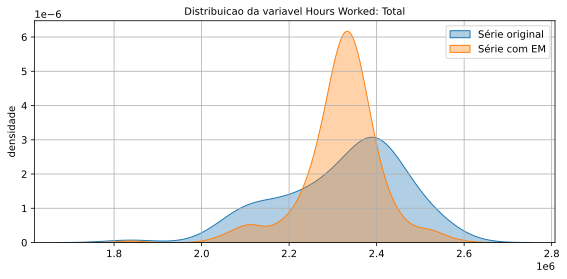

In [14]:
# Função densidade para as variáveis trimestrais - comparação entre série original e série com EM

vars_q = ea_qd.columns.intersection(df.columns).intersection(df_EM.columns)

# for col in vars_q[:10]:
for col in ["THOURS_PT_ea-qd"]:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col].dropna(), label=f"Série original", fill=True, alpha=0.35)
    sns.kdeplot(df_EM[col].dropna(), label=f"Série com EM", fill=True, alpha=0.35)
    plt.xlabel("")
    plt.ylabel("densidade")
    plt.title(f"Distribuicao da variavel Hours Worked: Total", fontsize=10)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [15]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

vars_q = (ea_qd.columns.intersection(df_EM.columns).intersection(df.columns))

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_EM": df_EM[vars_q].mean()
})
means["diff"] = means["mean_df_EM"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                        mean_df    mean_df_EM         diff     abs_diff
NFCLB_PT_ea-qd     5.846557e+05  5.868375e+05  2181.723055  2181.723055
THOURS_PT_ea-qd    2.322888e+06  2.320848e+06 -2039.695861  2039.695861
NFCASS_PT_ea-qd    3.336295e+05  3.356360e+05  2006.458558  2006.458558
HHASS_PT_ea-qd     3.861459e+05  3.874528e+05  1306.936174  1306.936174
TASS.LLN_PT_ea-qd  3.087755e+05  3.080218e+05  -753.719499   753.719499

Maior afastamento: NFCLB_PT_ea-qd
mean_df       584655.743204
mean_df_EM    586837.466259
diff            2181.723055
abs_diff        2181.723055
Name: NFCLB_PT_ea-qd, dtype: float64


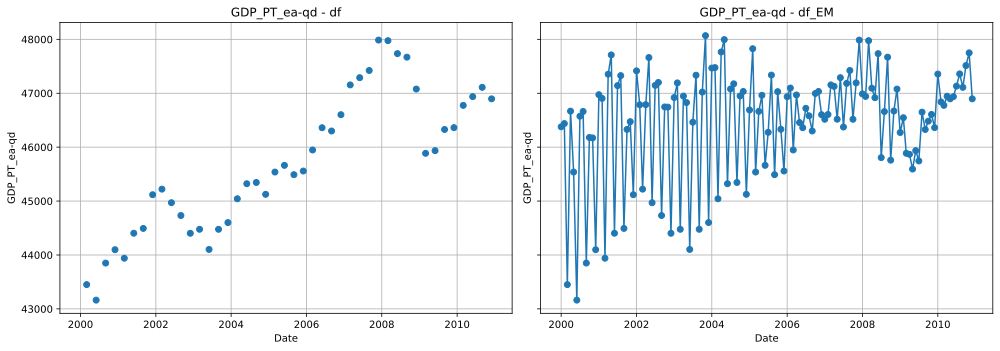

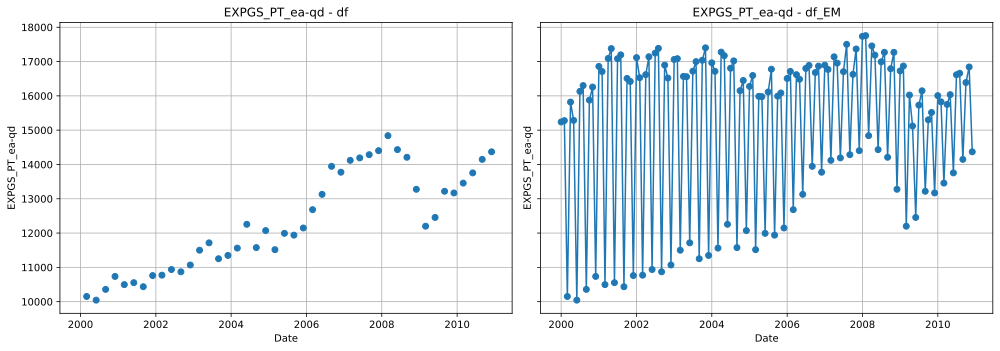

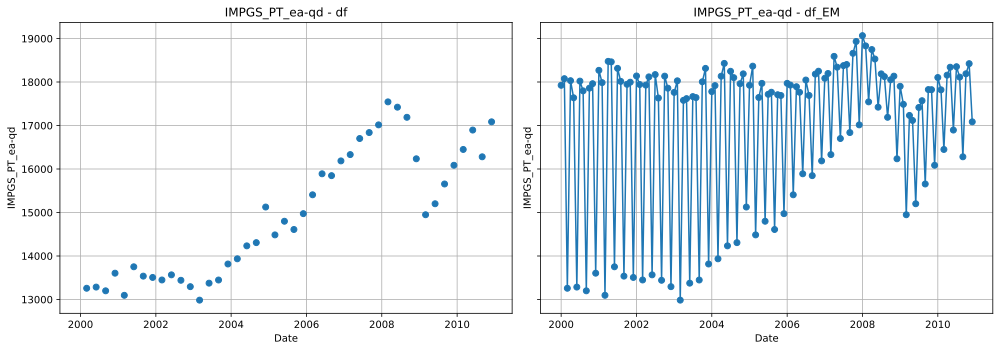

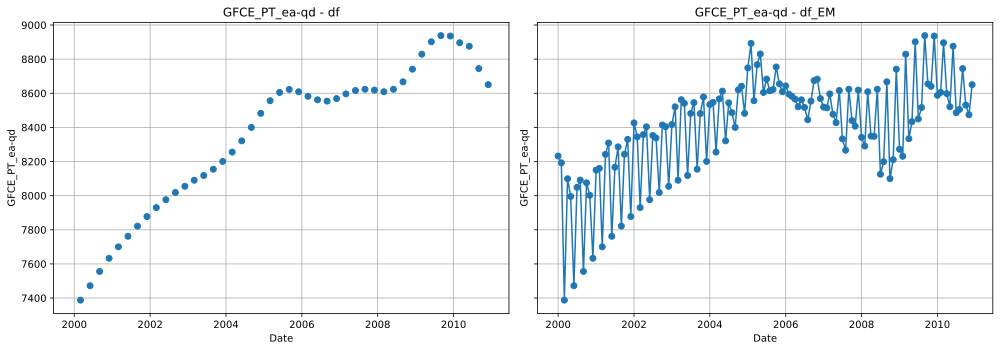

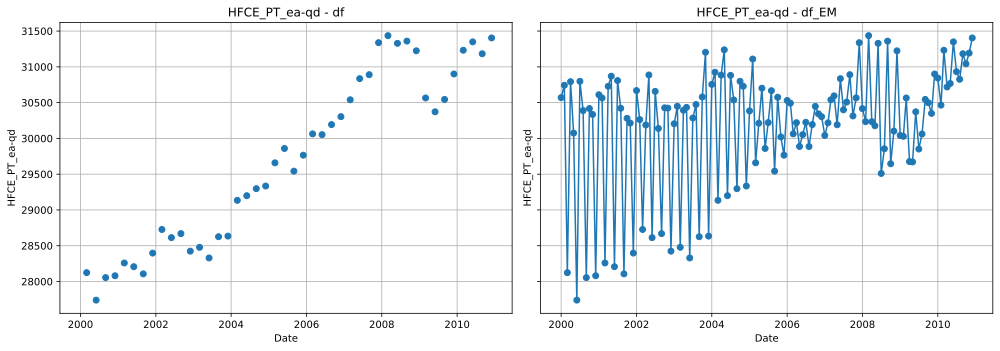

In [16]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com EM
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_EM.columns]

for col in vars_q[:5]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com EM
    serie_EM = df_EM.loc[start:end, col].dropna()
    axes[1].plot(serie_EM.index, serie_EM.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_EM")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


---

### **Interpolação**

Nesta fase testa-se a imputacao por **interpolação temporal**, uma alternativa mais local ao EM. Em vez de usar a estrutura conjunta de todo o painel, a interpolação reconstrói os valores em falta a partir da própria dinâmica de cada série.

***Teste de varios metodos e escolha por proximidade da média***

A estratégia seguida consiste em experimentar vários métodos de interpolação mantendo os restantes parâmetros fixos. Para cada série com valores em falta, compara-se a média original com a média após o preenchimento. O método eligido é aquele que produz a menor diferença absoluta das médias. Este critério é simples e fácil de interpretar, servindo como filtro inicial para identificar o método que menos altera o nível médio da série.


In [17]:
# Função para aplicar o melhor método de interpolação em cada série

def interpolate_best_by_series(
    df,
    metodos=None,
    limit=2,
    limit_direction="both",
    limit_area="inside",
    spline_order=3,
    return_info=True
):
    if metodos is None:
        metodos = [
            "linear",
            "time",
            "index",
            "nearest",
            "slinear",
            "quadratic",
            "cubic",
            "pchip",
            "akima",
            "cubicspline",
            "spline",
            "polynomial"
        ]



    df_base = df.copy()

    # se o índice não for datetime, o método "time" não funciona corretamente
    if not isinstance(df_base.index, pd.DatetimeIndex):
        metodos = [m for m in metodos if m != "time"]

    df_best = df_base.copy()
    resultados = []

    for col in df_base.columns:
        s = df_base[col]

        # ignorar colunas sem NaN
        if not s.isna().any():
            continue

        media_original = s.mean(skipna=True)

        melhor_diff = np.inf
        melhor_serie = s.copy()

        for metodo in metodos:
            try:
                kwargs = {
                    "method": metodo,
                    "limit": limit,
                    "limit_direction": limit_direction,
                    "limit_area": limit_area
                }

                # métodos que precisam de ordem
                if metodo in ["polynomial", "spline"]:
                    kwargs["order"] = spline_order

                s_fill = s.interpolate(**kwargs)

                media_fill = s_fill.mean(skipna=True)
                diff = abs(media_fill - media_original)

                resultados.append({
                    "serie": col,
                    "metodo": metodo,
                    "media_original": media_original,
                    "media_preenchida": media_fill,
                    "diff_media": diff
                })

                if diff < melhor_diff:
                    melhor_diff = diff
                    melhor_serie = s_fill

            except Exception:
                continue

        df_best[col] = melhor_serie

    resumo_metodos = pd.DataFrame(resultados)

    if resumo_metodos.empty:
        melhor_por_serie = pd.DataFrame(
            columns=["serie", "metodo", "media_original", "media_preenchida", "diff_media"]
        )
    else:
        resumo_metodos = resumo_metodos.sort_values(["serie", "diff_media"]).reset_index(drop=True)
        melhor_por_serie = (
            resumo_metodos
            .groupby("serie", as_index=False)
            .first()
            .sort_values("diff_media")
            .reset_index(drop=True)
        )

    if return_info:
        return df_best, melhor_por_serie, resumo_metodos

    return df_best



In [18]:
df_interpolated, info_melhores, info_completa = interpolate_best_by_series(df)

print(info_melhores.to_string())

c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packag

                  serie       metodo  media_original  media_preenchida   diff_media
0   CUSR0000SAC_fred-md       linear    1.803843e+02      1.803843e+02     0.000000
1         RPRP_PT_ea-qd        cubic    9.748886e+01      9.748903e+01     0.000165
2       GNFCIR_PT_ea-qd    quadratic    2.570660e+01      2.570643e+01     0.000168
3        ULCFC_PT_ea-qd       spline    9.380707e+01      9.380729e+01     0.000222
4        ULCRE_PT_ea-qd       spline    1.021889e+02      1.021857e+02     0.003238
5       GNFCPS_PT_ea-qd        cubic    3.801806e+01      3.802255e+01     0.004489
6         GHSR_PT_ea-qd        cubic    9.558252e+00      9.544013e+00     0.014239
7         GHIR_PT_ea-qd       linear    6.979709e+00      6.961792e+00     0.017917
8        EMPFC_PT_ea-qd        cubic    8.728359e+01      8.725825e+01     0.025343
9        EMPRT_PT_ea-qd         time    1.194716e+03      1.194682e+03     0.033887
10       DFGDP_PT_ea-qd         time    9.921848e+01      9.917690e+01     0

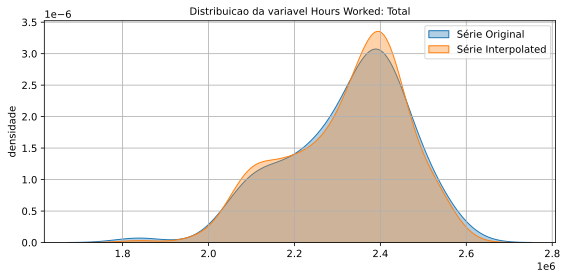

In [19]:
# Função densidade para as variáveis trimestrais - comparação entre série original e série com interpolação

vars_q = ea_qd.columns.intersection(df.columns).intersection(df_interpolated.columns)

# for col in vars_q[:10]:
for col in ["THOURS_PT_ea-qd"]:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col].dropna(), label=f"Série Original", fill=True, alpha=0.35)
    sns.kdeplot(df_interpolated[col].dropna(), label=f"Série Interpolated", fill=True, alpha=0.35)
    plt.xlabel("")
    plt.ylabel("densidade")
    plt.title(f"Distribuicao da variavel Hours Worked: Total", fontsize=10)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

vars_q = (
    ea_qd.columns
    .intersection(df_interpolated.columns)
    .intersection(df.columns)
)

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_interpolated": df_interpolated[vars_q].mean()
})
means["diff"] = means["mean_df_interpolated"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                         mean_df  mean_df_interpolated         diff  \
THOURS_PT_ea-qd     2.322888e+06          2.321767e+06 -1120.791847   
TLB.LLN_PT_ea-qd    3.674742e+05          3.680158e+05   541.612085   
TASS.LLN_PT_ea-qd   3.087755e+05          3.092551e+05   479.585187   
NFCLB.LLN_PT_ea-qd  1.369584e+05          1.371547e+05   196.288537   
GGASS_PT_ea-qd      1.190845e+05          1.188951e+05  -189.440408   

                       abs_diff  
THOURS_PT_ea-qd     1120.791847  
TLB.LLN_PT_ea-qd     541.612085  
TASS.LLN_PT_ea-qd    479.585187  
NFCLB.LLN_PT_ea-qd   196.288537  
GGASS_PT_ea-qd       189.440408  

Maior afastamento: THOURS_PT_ea-qd
mean_df                 2.322888e+06
mean_df_interpolated    2.321767e+06
diff                   -1.120792e+03
abs_diff                1.120792e+03
Name: THOURS_PT_ea-qd, dtype: float64


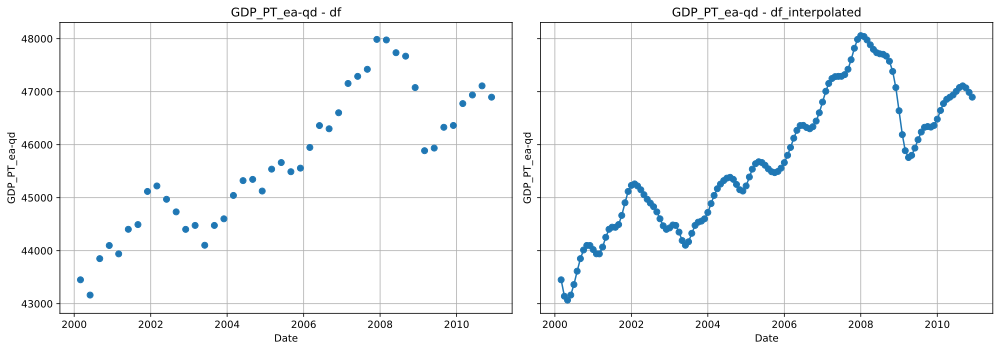

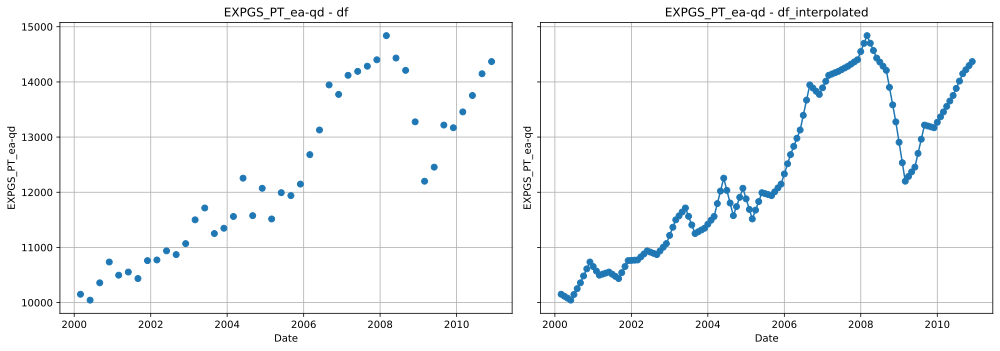

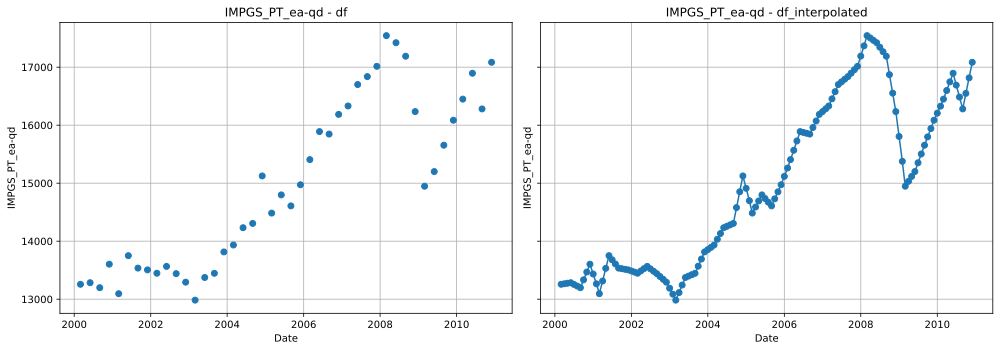

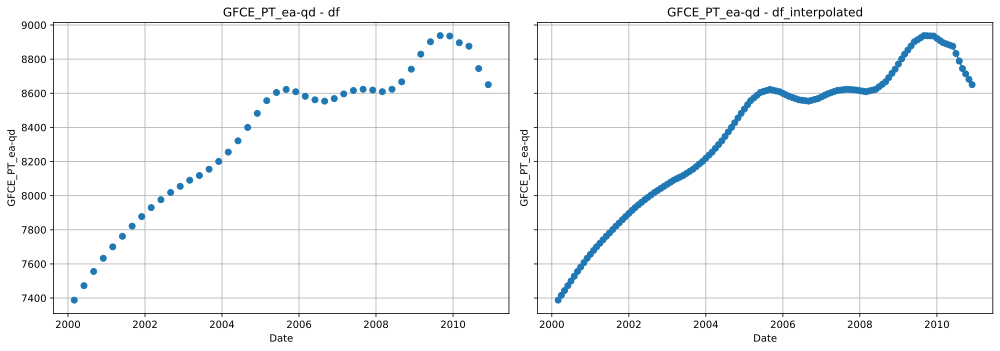

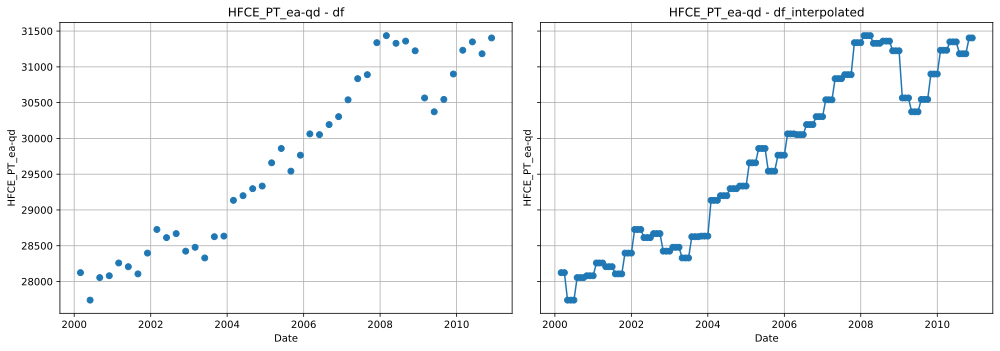

In [21]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com Interpolate
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_interpolated.columns]

#for col in ["THOURS_PT_ea-qd"]: # variável com maior desfasmento das médias
for col in vars_q[:5]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com Interpolate
    serie_interpolate = df_interpolated.loc[start:end, col].dropna()
    axes[1].plot(serie_interpolate.index, serie_interpolate.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_interpolated")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


---


### **Expectation Maximization + Interpolacao**

Depois de analisar separadamente o EM e a Interpolacao, esta secção combina os dois métodos numa abordagem híbrida. A lógica é aproveitar o ponto forte de cada técnica em partes diferentes das séries trimestrais.

#### ***Regra de combinação adotada***

Na versão híbrida, a **interpolacao** é usada para preencher os valores internos entre observações reais, enquanto o **EM** é utilizado nas extremidades das séries trimestrais, isto é, antes do primeiro valor válido e depois do último valor observado.

Esta opção procura reduzir a distorção introduzida pelo EM nos intervalos internos, mantendo ao mesmo tempo uma solução para as *ragged edges*, onde a interpolação deixa naturalmente valores por preencher.


In [22]:

def hybrid_em_interpolation(
    df,
    cols_target=None,
    q0=99,
    em_opts=None,
    interpolation_kwargs=None,
    return_parts=True
):
    """
    Método híbrido:
    - EM nas ragged edges
    - interpolação nos NaN internos
    - valores observados ficam intocados

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com indice temporal e colunas numéricas.
    cols_target : list-like or None
        Colunas onde a logica hibrida sera aplicada.
        Se None, aplica a todas as colunas do df.
    q0 : int
        Numero de fatores do EM. Usa 99 para selecao Bai-Ng.
    em_opts : dict or None
        Opcoes para EMimputation.
    interpolation_func : callable or None
        Funcao que recebe um df e devolve um df interpolado.
        Ex.: interpolate_best_by_series
    return_parts : bool
        Se True, devolve também df_em, df_interp e tabelas auxiliares.
        
    Returns
    -------
    df_hybrid : pd.DataFrame
        DataFrame final com método híbrido.
    df_em : pd.DataFrame, opcional
        DataFrame preenchido apenas com EM.
    df_interp : pd.DataFrame, opcional
        DataFrame preenchido apenas com interpolação.
    info_melhores : pd.DataFrame, opcional
        Melhor método de interpolação por série.
    info_completa : pd.DataFrame, opcional
        Resultado completo dos métodos testados.
    pc : dict, opcional
        Estrutura devolvida pelo EMimputation.
    """

    df_base = df.copy()

    if cols_target is None:
        cols_target = df_base.columns.tolist()
    else:
        cols_target = [col for col in cols_target if col in df_base.columns]

    # 1) EM
    em_result = apply_em_imputation(
        df_base,
        q0=q0,
        opts=em_opts,
        return_factors=True
    )
    df_em, pc = em_result

    # 2) Interpolação
    if interpolation_kwargs is None:
        interpolation_kwargs = {}

    interp_result = interpolate_best_by_series(df_base, **interpolation_kwargs)

    if isinstance(interp_result, tuple):
        df_interp = interp_result[0]
        info_melhores = interp_result[1]
        info_completa = interp_result[2]
    else:
        df_interp = interp_result
        info_melhores = None
        info_completa = None

    # 3) Construção do híbrido
    df_hybrid = df_interp.copy()

    for col in cols_target:
        s = df_base[col]

        first_valid = s.first_valid_index()
        last_valid = s.last_valid_index()

        if first_valid is None or last_valid is None:
            continue

        lead_mask = s.index < first_valid
        trail_mask = s.index > last_valid
        obs_mask = s.notna()

        # EM nas pontas
        df_hybrid.loc[lead_mask, col] = df_em.loc[lead_mask, col]
        df_hybrid.loc[trail_mask, col] = df_em.loc[trail_mask, col]

        # valores observados mantêm-se iguais ao original
        df_hybrid.loc[obs_mask, col] = s.loc[obs_mask]

    if return_parts:
        return df_hybrid, df_em, df_interp, info_melhores, info_completa, pc

    return df_hybrid


In [23]:
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns]
# Adicionar "CUSR0000SAC_fred-md" à lista para aplicar o método híbriido, pois contem valores omissos
vars_q.append("CUSR0000SAC_fred-md")

df_hybrid, df_em, df_interp, info_melhores, info_completa, pc = hybrid_em_interpolation(
    df=df,
    cols_target=vars_q,
    interpolation_kwargs={"return_info": True}
)


Running iteration 0: error is 999.000000
Running iteration 10: error is   0.000103
Running iteration 20: error is   0.000028
Running iteration 30: error is   0.000013
EM converged after 35 iterations


c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
c:\Users\sasah\AppData\Local\Programs\Python\Python313\Lib\site-packag

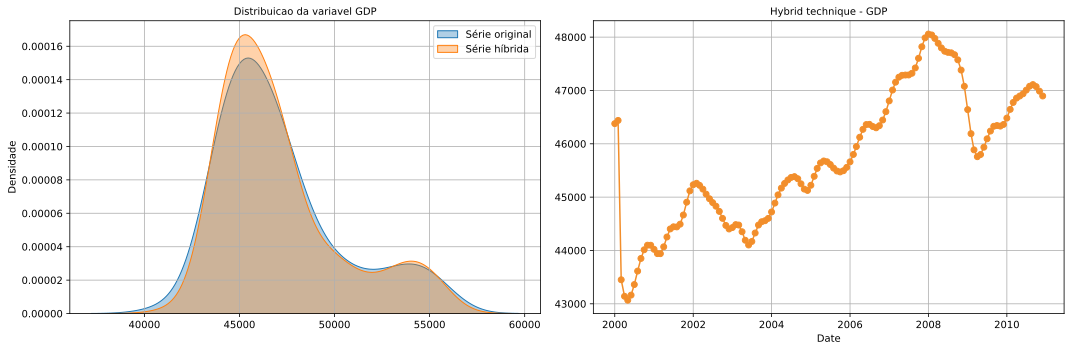

In [39]:
# Comparação entre densidade da série original vs híbrida
# e série transformada ao longo do tempo

start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_hybrid.columns]
blue = "#5B8CC0"
orange = "#F28E2B"
for col in ["GDP_PT_ea-qd"]:
    serie_original = df.loc[start:end, col].dropna()
    serie_hybrid = df_hybrid.loc[start:end, col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.subplots_adjust(wspace=0.30)

    # Densidades
    sns.kdeplot(
        df[col].dropna(),
        label="Série original",
        fill=True,
        alpha=0.35,
        ax=axes[0]
    )
    sns.kdeplot(
        df_hybrid[col].dropna(),
        label="Série híbrida",
        fill=True,
        alpha=0.35,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribuicao da variavel GDP", fontsize=10)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Densidade")
    axes[0].legend()
    axes[0].grid(True)

    # Série ao longo do tempo
    axes[1].plot(
        serie_hybrid.index,
        serie_hybrid.values,
        marker="o",
        linestyle="-",
        color=orange,
    )
    axes[1].set_title(f"Hybrid technique - GDP", fontsize=10)
    axes[1].set_xlabel("Date")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


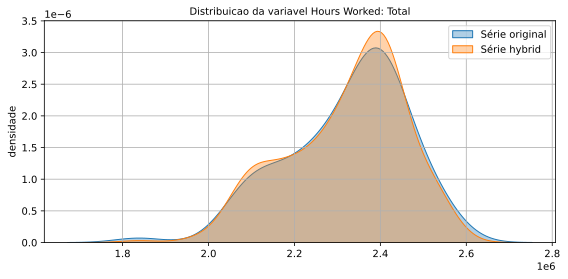

In [30]:
# Função densidade para as variáveis trimestrais - comparação entre série original e série com técnica híbrida

vars_q = ea_qd.columns.intersection(df.columns).intersection(df_hybrid.columns)

# for col in vars_q[:10]:
for col in ["THOURS_PT_ea-qd"]:
    
    # Comparação das distribuições
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col].dropna(), label=f"Série original", fill=True, alpha=0.35)
    sns.kdeplot(df_hybrid[col].dropna(), label=f"Série hybrid", fill=True, alpha=0.35)
    plt.title(f"Distribuicao da variavel Hours Worked: Total", fontsize=10)
    plt.xlabel("")
    plt.ylabel("densidade")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [25]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

# Variáveis trimestrais comuns
vars_q = (
    ea_qd.columns
    .intersection(df_hybrid.columns)
    .intersection(df.columns)
)

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_hybrid": df_hybrid[vars_q].mean()
})
means["diff"] = means["mean_df_hybrid"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                        mean_df  mean_df_hybrid         diff     abs_diff
THOURS_PT_ea-qd    2.322888e+06    2.321468e+06 -1420.023889  1420.023889
TLB.LLN_PT_ea-qd   3.674742e+05    3.678078e+05   333.657574   333.657574
TASS.LLN_PT_ea-qd  3.087755e+05    3.090942e+05   318.735138   318.735138
TLB.LBD_PT_ea-qd   2.043941e+05    2.045567e+05   162.561200   162.561200
HHASS_PT_ea-qd     3.861459e+05    3.860142e+05  -131.733082   131.733082

Maior afastamento: THOURS_PT_ea-qd
mean_df           2.322888e+06
mean_df_hybrid    2.321468e+06
diff             -1.420024e+03
abs_diff          1.420024e+03
Name: THOURS_PT_ea-qd, dtype: float64


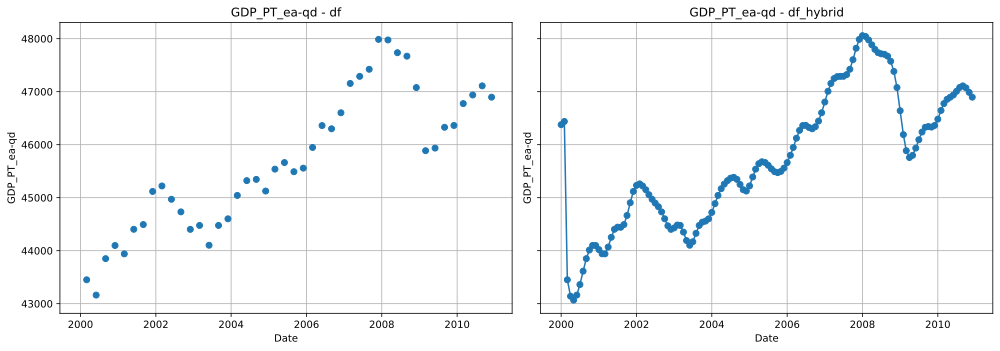

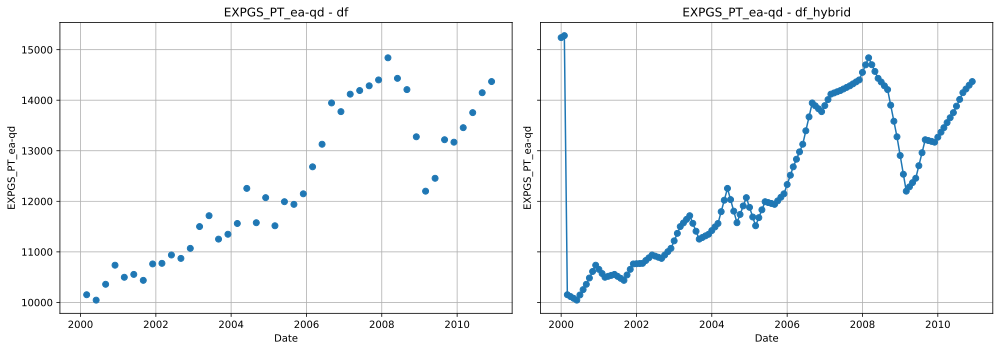

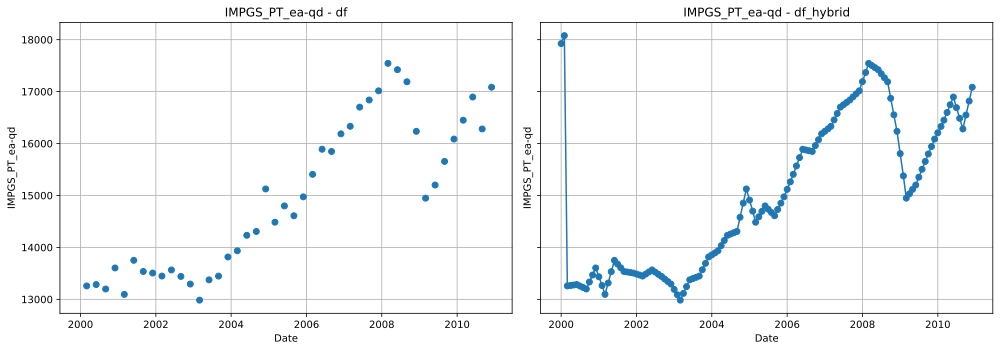

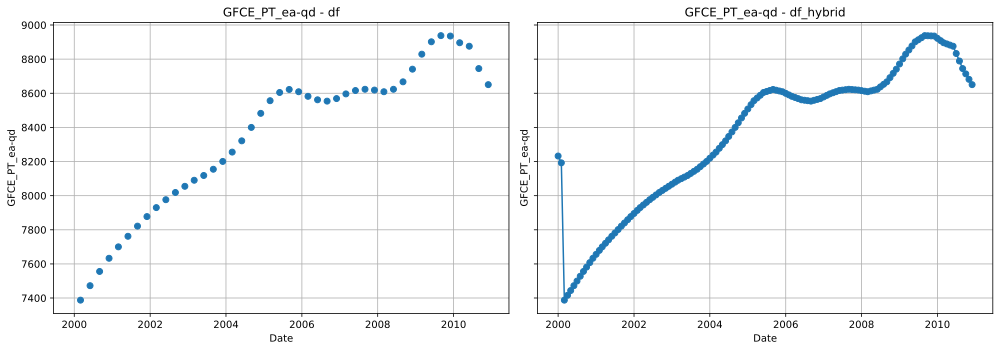

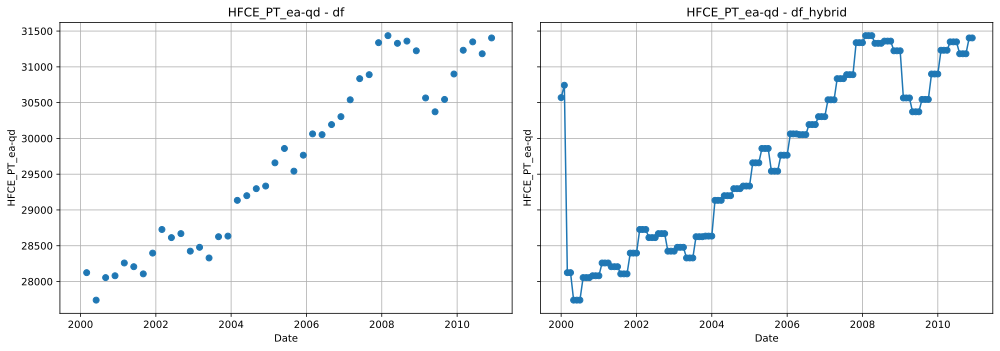

In [26]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com a técnica híbrida
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_hybrid.columns]

#for col in ["THOURS_PT_ea-qd"]: # variável com maior desfasmento das médias
for col in vars_q[:5]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com a tecnica híbrida
    serie_hybrid = df_hybrid.loc[start:end, col].dropna()
    axes[1].plot(serie_hybrid.index, serie_hybrid.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_hybrid")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


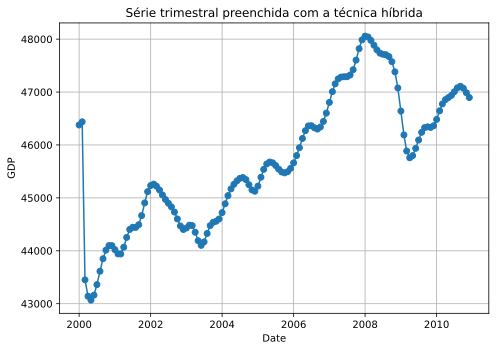

In [27]:
import matplotlib.pyplot as plt

start, end = "2000-01-01", "2010-12-01"
col = "GDP_PT_ea-qd"

serie = df_hybrid.loc[start:end, col].dropna()

plt.figure(figsize=(7, 5))
plt.plot(serie.index, serie.values, marker="o", linestyle="-")
plt.title(f"Série trimestral preenchida com a técnica híbrida")
plt.xlabel("Date")
plt.ylabel("GDP")
plt.grid(True)
plt.tight_layout()
plt.show()


---

In [ ]:
# Guardar o DataFrame híbrido final para análises posteriores
#df_hybrid.to_csv("Data_Hybrid.csv", index=True)

---